In [1]:
#批归一化
# 统一部分
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print(sys.version_info)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

print(len(train_dataset))
print(len(test_dataset))

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(class_names)
print(len(class_names))

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=4)

sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
cuda:0
60000
10000
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
10


In [2]:
#DNN建立

import torch.nn as nn
import torch.nn.functional as F

class DNN(nn.Module):
    def __init__(self, input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10):
        super(DNN, self).__init__()

        layers = []
        
        #第一隐藏层
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.SELU())
        
        # 隐藏层
        for i in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.SELU())
        
        # 输出层
        layers.append(nn.Linear(hidden_size, num_classes))
        
        self.linear_selu_stack = nn.Sequential(*layers)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.linear_selu_stack(x)
        return x
    
model = DNN(input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10)

print(model)
print(sum(p.numel() for p in model.parameters()))

DNN(
  (linear_selu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): SELU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): SELU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): SELU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): SELU()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): SELU()
    (10): Linear(in_features=256, out_features=256, bias=True)
    (11): SELU()
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): SELU()
    (14): Linear(in_features=256, out_features=256, bias=True)
    (15): SELU()
    (16): Linear(in_features=256, out_features=256, bias=True)
    (17): SELU()
    (18): Linear(in_features=256, out_features=256, bias=True)
    (19): SELU()
    (20): Linear(in_features=256, out_features=256, bias=True)
    (21): SELU()
    (22): Linear(in_features=256, out_features=256, bias=True)
    (23): SELU()
    (24): 

In [3]:
batch_size = 64
input_tensor = torch.randn(batch_size, 1, 28, 28)

print(input_tensor.shape)

with torch.no_grad():
    output = model(input_tensor)

print(output.shape)

assert output.shape == (batch_size, 10), f"期望输出形状为 ({batch_size}, 10), 但得到 {output.shape}"
print("测试通过")

for batch in train_loader:
    inputs, targets = batch
    print(inputs.shape)
    print(targets.shape)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])
测试通过
torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
from my_trainer_for_t1 import Trainer

device = torch.device("cuda")
print(f"使用设备: {device}")

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

early_stopping_kwargs = {
    'patience': 10,
    'min_delta': 0.001,
    'mode': 'max'
}

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500,
    early_stopping_kwargs=early_stopping_kwargs
)

trainer.train(num_epochs=20)

使用设备: cuda
[Step 500] Val Loss: 0.9555 Val Acc: 0.6362
Epoch [1/20]  Train Loss: 1.1487  Train Acc: 0.5789
[Step 1000] Val Loss: 0.6882 Val Acc: 0.7801
[Step 1500] Val Loss: 0.4915 Val Acc: 0.8736
Epoch [2/20]  Train Loss: 0.6652  Train Acc: 0.8189
[Step 2000] Val Loss: 0.4605 Val Acc: 0.8871
[Step 2500] Val Loss: 0.4504 Val Acc: 0.8813
Epoch [3/20]  Train Loss: 0.5142  Train Acc: 0.8677
[Step 3000] Val Loss: 1.3334 Val Acc: 0.5393
[Step 3500] Val Loss: 0.6087 Val Acc: 0.8288
Epoch [4/20]  Train Loss: 0.8471  Train Acc: 0.7262
[Step 4000] Val Loss: 0.4048 Val Acc: 0.8951
[Step 4500] Val Loss: 0.3764 Val Acc: 0.9054
Epoch [5/20]  Train Loss: 0.4000  Train Acc: 0.8990
[Step 5000] Val Loss: 0.2910 Val Acc: 0.9249
[Step 5500] Val Loss: 0.4414 Val Acc: 0.8845
Epoch [6/20]  Train Loss: 0.3106  Train Acc: 0.9221
[Step 6000] Val Loss: 0.3090 Val Acc: 0.9259
[Step 6500] Val Loss: 0.6174 Val Acc: 0.8078
Epoch [7/20]  Train Loss: 0.3415  Train Acc: 0.9113
[Step 7000] Val Loss: 0.4366 Val Acc: 0.8

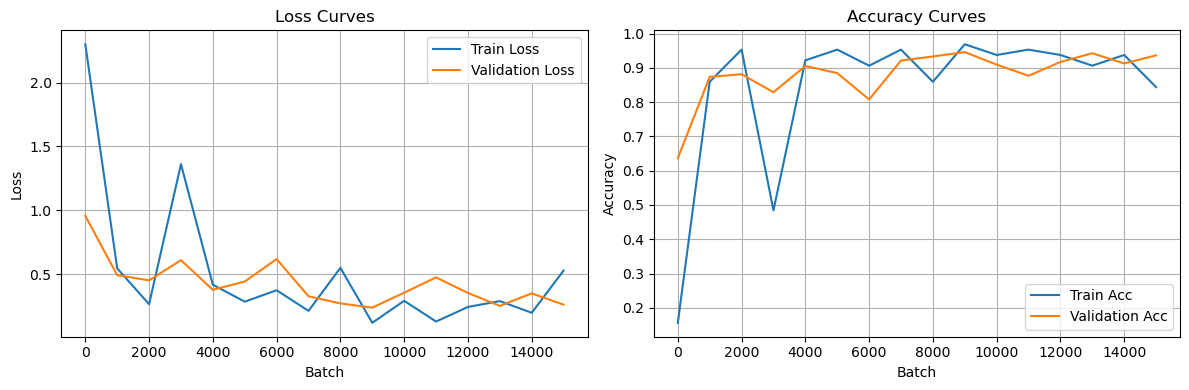

In [5]:
trainer.plot_curves()